# Model 4: XGBoost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

In [4]:
df = pd.read_csv("data/final_df.csv")

In [5]:
# Drop non-feature columns
drop_cols = ['filename', 'length', 'label', 'final_group']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['final_group']

# XGBoost requires integer labels — encode them
le = LabelEncoder()  # Acoustic=0, Electric=1, Rhythmic=2 (alphabetical)
y_enc = le.fit_transform(y)

print(f'Features : {X.shape[1]}')
print(f'Classes  : {list(le.classes_)} -> {list(range(len(le.classes_)))}')

Features : 57
Classes  : ['Acoustic', 'Electric', 'Rhythmic'] -> [0, 1, 2]


In [6]:
# Stratified 80/20 split — same seed as RF for a fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train : {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')
print(f'\nTrain class distribution (encoded):')
unique, counts = np.unique(y_train, return_counts=True)
for cls, n in zip(le.classes_, counts):
    print(f'  {cls}: {n}')

Train : (800, 57)  |  Test: (200, 57)

Train class distribution (encoded):
  Acoustic: 240
  Electric: 240
  Rhythmic: 320


In [7]:
# Baseline XGBoost model with default parameters

xgb_baseline = XGBClassifier(
    n_estimators=100,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_baseline.fit(X_train_scaled, y_train)
y_pred_base = xgb_baseline.predict(X_test_scaled)

acc_base  = accuracy_score(y_test, y_pred_base)
f1_w_base = f1_score(y_test, y_pred_base, average='weighted')
f1_m_base = f1_score(y_test, y_pred_base, average='macro')

print('=== Baseline XGBoost ===')
print(f'Accuracy   : {acc_base:.4f}')
print(f'Weighted F1: {f1_w_base:.4f}')
print(f'Macro F1   : {f1_m_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [21:36:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Baseline XGBoost ===
Accuracy   : 0.8600
Weighted F1: 0.8603
Macro F1   : 0.8624

              precision    recall  f1-score   support

    Acoustic       0.91      0.88      0.90        60
    Electric       0.86      0.83      0.85        60
    Rhythmic       0.82      0.86      0.84        80

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



In [8]:
# 5-fold cross-validation — consistent with RF notebook
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    XGBClassifier(
        n_estimators=100,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ),
    X, y_enc, cv=cv, scoring='accuracy'
)
print(f'5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold          : {np.round(cv_scores, 4)}')

C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [21:36:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [21:36:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [21:36:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [21:36:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.

5-fold CV Accuracy: 0.8190 ± 0.0156
Per-fold          : [0.83  0.82  0.82  0.79  0.835]


## 3. Hyperparameter Tuning (GridSearchCV)

Key XGBoost knobs:
- `n_estimators` — number of boosting rounds
- `max_depth` — tree depth (controls model complexity)
- `learning_rate` — shrinkage applied to each tree's contribution
- `subsample` — fraction of training rows sampled per tree (reduces overfitting)
- `colsample_bytree` — fraction of features sampled per tree (like `max_features` in RF)

In [9]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_scaled, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV acc : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [22:01:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV acc : 0.8212


In [10]:
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)

acc_best  = accuracy_score(y_test, y_pred_best)
f1_w_best = f1_score(y_test, y_pred_best, average='weighted')
f1_m_best = f1_score(y_test, y_pred_best, average='macro')

print('=== Tuned XGBoost ===')
print(f'Accuracy   : {acc_best:.4f}')
print(f'Weighted F1: {f1_w_best:.4f}')
print(f'Macro F1   : {f1_m_best:.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

=== Tuned XGBoost ===
Accuracy   : 0.8600
Weighted F1: 0.8604
Macro F1   : 0.8613

              precision    recall  f1-score   support

    Acoustic       0.95      0.87      0.90        60
    Electric       0.86      0.80      0.83        60
    Rhythmic       0.81      0.90      0.85        80

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200



C:\Users\Archi\AppData\Roaming\Python\Python310\site-packages\xgboost\callback.py:385: UserWarning: [22:01:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


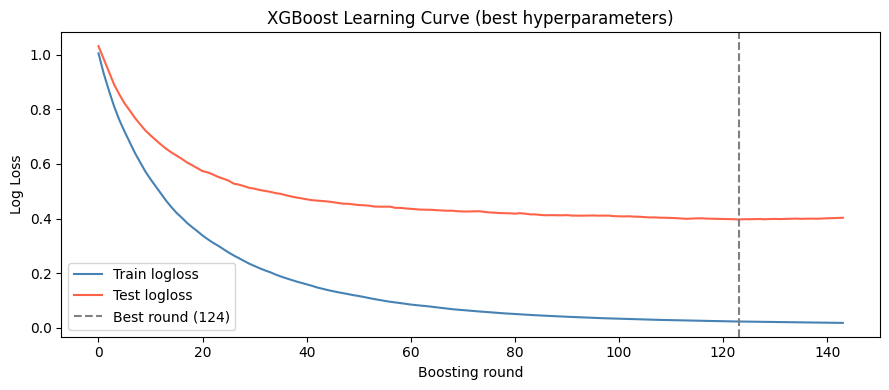

Best round  : 124
Min test loss: 0.3968


In [11]:
# Learning curve — shows how test logloss evolves over boosting rounds
# Helps diagnose overfitting vs underfitting
best_params = grid_search.best_params_.copy()

xgb_eval = XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)

xgb_eval.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

results = xgb_eval.evals_result()
train_loss = results['validation_0']['mlogloss']
test_loss  = results['validation_1']['mlogloss']

plt.figure(figsize=(9, 4))
plt.plot(train_loss, label='Train logloss', color='steelblue')
plt.plot(test_loss,  label='Test logloss',  color='tomato')
plt.axvline(x=np.argmin(test_loss), color='grey', linestyle='--',
            label=f'Best round ({np.argmin(test_loss)+1})')
plt.xlabel('Boosting round')
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curve (best hyperparameters)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best round  : {np.argmin(test_loss)+1}')
print(f'Min test loss: {min(test_loss):.4f}')

feature imp

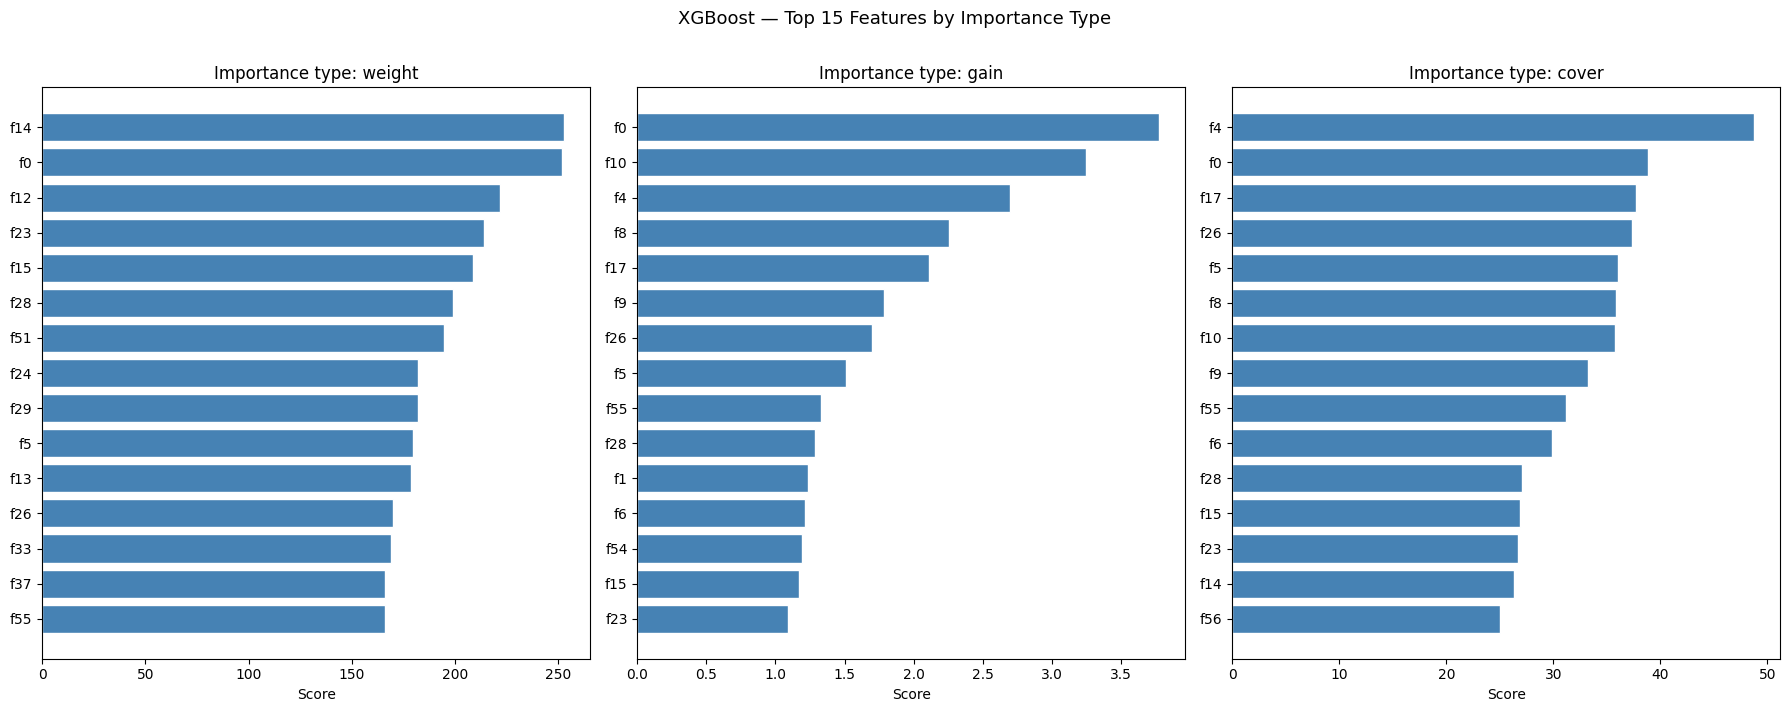

In [12]:
# XGBoost offers three importance types:
#   'weight'  — number of times a feature is used to split across all trees
#   'gain'    — average loss reduction gained when feature is used (most informative)
#   'cover'   — average number of samples affected by splits on this feature

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
importance_types = ['weight', 'gain', 'cover']

for ax, imp_type in zip(axes, importance_types):
    scores = best_xgb.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame({
        'feature'   : list(scores.keys()),
        'importance': list(scores.values())
    }).sort_values('importance', ascending=False).head(15)

    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_title(f'Importance type: {imp_type}')
    ax.set_xlabel('Score')

plt.suptitle('XGBoost — Top 15 Features by Importance Type', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Gain-based importance as a clean ranked table
gain_scores = best_xgb.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame({
    'feature'   : list(gain_scores.keys()),
    'gain'      : list(gain_scores.values())
}).sort_values('gain', ascending=False)

print('Top 20 features by Gain:')
print(gain_df.head(20).to_string(index=False))

Top 20 features by Gain:
feature     gain
     f0 3.775406
    f10 3.245982
     f4 2.694344
     f8 2.256964
    f17 2.112227
     f9 1.783750
    f26 1.700155
     f5 1.507532
    f55 1.326124
    f28 1.287089
     f1 1.237606
     f6 1.212087
    f54 1.189654
    f15 1.167684
    f23 1.089539
     f3 1.007777
    f52 1.000603
    f24 0.982819
    f13 0.897354
    f56 0.860812


evaluation and congusion matrix

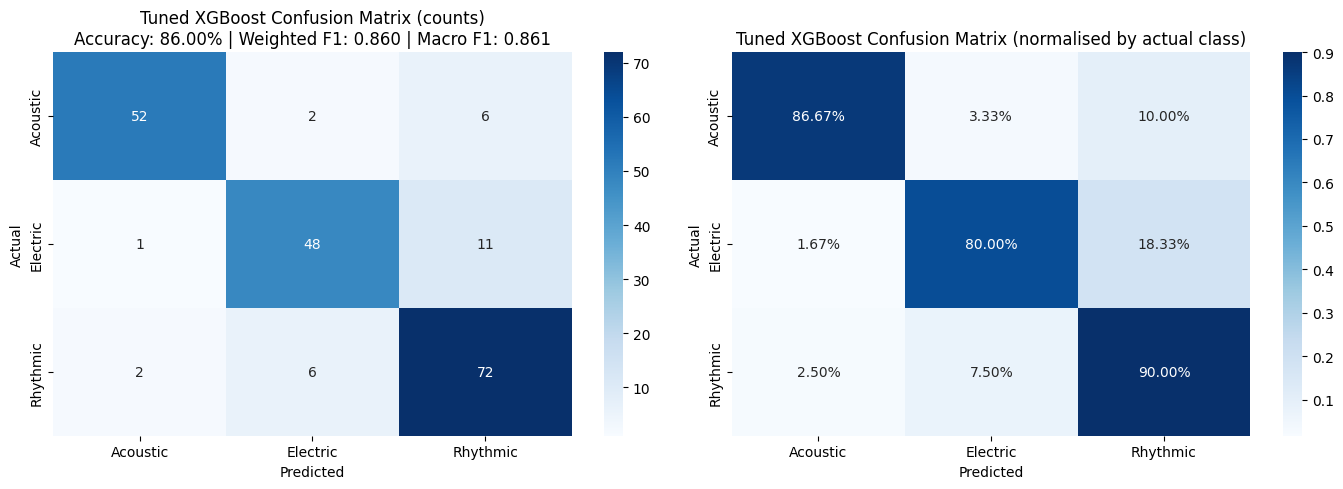

In [14]:
labels = le.classes_  # ['Acoustic', 'Electric', 'Rhythmic']
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(
    f'Tuned XGBoost Confusion Matrix (counts)\n'
    f'Accuracy: {acc_best:.2%} | Weighted F1: {f1_w_best:.3f} | Macro F1: {f1_m_best:.3f}'
)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Tuned XGBoost Confusion Matrix (normalised by actual class)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [16]:
# Summary comparison table — fill in results from other models as you go
comparison = pd.DataFrame({
    'Model'      : [
        'Naive Baseline (rolloff_mean)',
        'KNN (k=6)',
        'Random Forest (tuned)',
        'XGBoost (baseline)',
        'XGBoost (tuned)'
    ],
    'Accuracy'   : [0.552, 0.7267, 0.82, acc_base,  acc_best],
    'Weighted F1': [0.53, 0.73, 0.81, f1_w_base, f1_w_best],
    'Macro F1'   : [0.55, 0.73, 0.84, f1_m_base, f1_m_best]
})
print(comparison.to_string(index=False))

                        Model  Accuracy  Weighted F1  Macro F1
Naive Baseline (rolloff_mean)    0.5520     0.530000  0.550000
                    KNN (k=6)    0.7267     0.730000  0.730000
        Random Forest (tuned)    0.8200     0.810000  0.840000
           XGBoost (baseline)    0.8600     0.860314  0.862409
              XGBoost (tuned)    0.8600     0.860409  0.861335
